<a href="https://colab.research.google.com/github/kaitlynwarford/mlb-player-valuation/blob/main/PredictingPlayerValuation2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pybaseball

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.7/432.7 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 69.9 MB/s eta 0:00:00


In [19]:
from pybaseball import batting_stats, fg_batting_data
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor


# build aging curve

years = []
for y in range(2018, 2024):
    df = batting_stats(y)
    df["Season"] = y
    years.append(df)

multi = pd.concat(years, ignore_index=True)
multi = multi[["Name", "Season", "Age", "WAR"]].dropna()

next_year = multi.copy()
next_year["Season"] -= 1

merged_age = pd.merge(
    multi,
    next_year,
    on=["Name", "Season"],
    suffixes=("_t", "_t1")
)

merged_age["WAR_delta"] = merged_age["WAR_t1"] - merged_age["WAR_t"]
aging_curve = merged_age.groupby("Age_t")["WAR_delta"].mean()


# load data

hist = fg_batting_data(2023)

hist["ISO"] = hist["SLG"] - hist["AVG"]
hist["HR_rate"] = hist["HR"] / hist["PA"]
hist["Aging_Adjustment"] = hist["Age"].map(aging_curve).fillna(0)

cols = [
    "Name", "PA", "HR", "BB%", "K%", "OBP", "SLG", "WAR", "Age",
    "ISO", "HR_rate", "wRC+", "wOBA", "BABIP", "HardHit%", "Barrel%",
    "Aging_Adjustment"
]

hist = hist[cols].dropna()


# define features and train model

feature_cols = [
    "PA", "HR", "BB%", "K%", "OBP", "SLG", "Age",
    "ISO", "HR_rate", "wRC+", "wOBA", "BABIP",
    "HardHit%", "Barrel%", "Aging_Adjustment"
]

X = hist[feature_cols]
Y = hist["WAR"]


X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, Y_train)

print("Train R2:", model.score(X_train, Y_train))
print("Test R2:", model.score(X_test, Y_test))


# load data and features

stats_2025 = fg_batting_data(2025)

stats_2025["ISO"] = stats_2025["SLG"] - stats_2025["AVG"]
stats_2025["HR_rate"] = stats_2025["HR"] / stats_2025["PA"]
stats_2025["Aging_Adjustment"] = stats_2025["Age"].map(aging_curve).fillna(0)


stats_2025 = stats_2025[feature_cols + ["Name"]].dropna()

# player evaluation function

def evaluate_player(name, salary=None):
  player = stats_2025[stats_2025['Name'].str.lower() == name.lower()]

  if player.empty:
    print('Player not found in 2025 dataset.')
    return

  war = float(player['Projected_WAR_2026'])
  value = war * 8000000

  print('f\n--- {name} ---')
  print(f'Projected WAR (2026): {war:.2f}')
  print(f'Estimated Dollar Value: ${value:.0f}')

  if salary is not None:
    surplus = value - salary
    print(f'Salary: ${salary:,.0f}')
    print(f'Surplus Value: ${surplus:,.0f}')


# project 2026 WAR

X_2026 = stats_2025[feature_cols]
stats_2025["Projected_WAR_2026"] = model.predict(X_2026)

dollars_per_war = 8000000

stats_2025['Dollar_Value'] = stats_2025['Projected_WAR_2026'] * dollars_per_war

stats_2025.sort_values("Projected_WAR_2026", ascending=False).head(20)

# create player valuation variable and function

def value_player(row, dollars_per_war=8000000, salary=None):
  war = row['Projected_WAR_2026']
  value = war * dollars_per_war

  if salary is not None:
    surplus = value - salary
    return pd.Series({
        'Projected_WAR_2026': war,
        'Dollar_Value': value,
        'Surplus_Value': surplus
    })
  else:
    return pd.Series({
        'Projected_WAR_2026': war,
        'Dollar_Value': value
    })

# interactive evaluation

def evaluate_player(name, salary=None):
  player = stats_2025[stats_2025['Name'] == name]

  if player.empty:
    print('Player not found.')
    return

  war = float(player['Projected_WAR_2026'])
  value = war * dollars_per_war

  print(f'--- {name} ---')
  print(f'Projected WAR (2026): {war:.2f}')
  print(f'Estimated Dollar Value: ${value:,.0f}')

  if salary is not None:
    surplus = value - salary
    print(f'Salary: ${salary:,.0f}')
    print(f'Surplus Value: ${surplus:,.0f}')

# add user input

player_name = input("Enter player's name: ")

salary_input = input("Enter player's salary (or press Enter to skip): ")

if salary_input.strip() == "":
  evaluate_player(player_name)
else:
  salary = float(salary_input)
  evaluate_player(player_name, salary)

Train R2: 0.9924376136718112
Test R2: 0.4153379811149662
Enter player's name: Aaron Judge
Enter player's salary (or press Enter to skip): 40000000
--- Aaron Judge ---
Projected WAR (2026): 6.18
Estimated Dollar Value: $49,432,060
Salary: $40,000,000
Surplus Value: $9,432,060


/tmp/ipython-input-805236546.py:144: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  war = float(player['Projected_WAR_2026'])


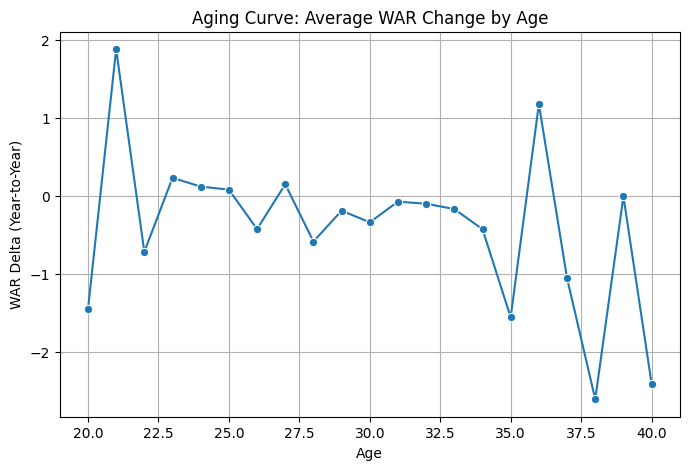

In [20]:
# build visualization - WAR change by age
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.lineplot(x=aging_curve.index, y=aging_curve.values, marker='o')
plt.title('Aging Curve: Average WAR Change by Age')
plt.xlabel('Age')
plt.ylabel('WAR Delta (Year-to-Year)')
plt.grid(True)
plt.show()

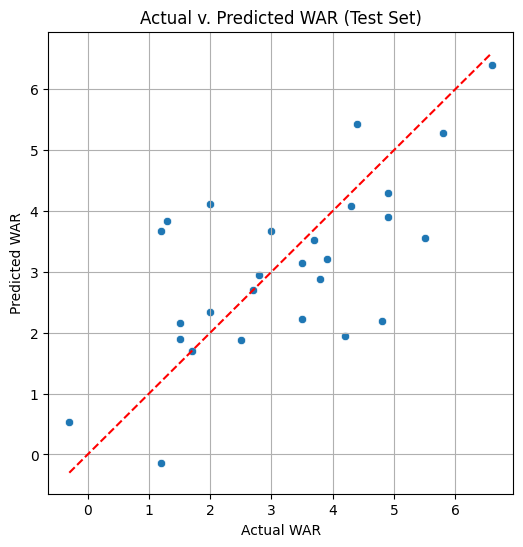

In [21]:
# build visualization - actual v. predicted WAR plot
Y_pred = model.predict(X_test)

plt.figure(figsize=(6,6))
sns.scatterplot(x=Y_test, y=Y_pred)
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         color='red', linestyle='--')
plt.xlabel('Actual WAR')
plt.ylabel('Predicted WAR')
plt.title('Actual v. Predicted WAR (Test Set)')
plt.grid(True)
plt.show()